# GA-Optimised Trading Strategies: Backtesting Results
### Walk-Forward Analysis Across Forex, Stocks & Crypto (2020–2025)

---

**Overview.** This notebook walks through the results of running a genetic algorithm (GA) to optimise five day-trading strategy families across three asset classes: forex (EURUSD, USDJPY), US equities (SPY, QQQ, AAPL, TSLA), and crypto (BTC, SOL). Each strategy was trained on 2020–2022 data, validated on 2023, and tested out-of-sample on 2024–2025. The GA ran 15 candidates per generation for 6 generations — roughly 90 backtests per strategy-asset combo.

The short version: **forex and stocks produced usable results; crypto was a dead end.** The best performers were USDJPY's Bollinger Band Bounce (+12.73%) and EURUSD's EMA Crossover (+8.55%). Most stock strategies squeeze out small positive returns. Crypto strategies flatlined at 0%.

This notebook covers the training distributions, out-of-sample results, overfitting gaps, and what actually worked versus what just looked good in-sample.


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings('ignore')

# Styling — keep it clean
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 110,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'figure.facecolor': 'white',
})

FAMILY_NAMES = {
    1: 'RSI Mean Reversion',
    2: 'Bollinger Band Bounce',
    3: 'EMA Crossover',
    4: 'Stochastic Mean Reversion',
    5: 'EMA Trend + ADX',
}

# For stocks the families are slightly different
STOCK_FAMILY_NAMES = {
    1: 'RSI Mean Reversion',
    2: 'Bollinger Band Mean Reversion',
    3: 'Connors RSI (2-Period)',
    4: 'EMA Trend + ADX',
    5: 'Williams %R + RSI',
}

ASSET_COLORS = {
    'EURUSD': '#2196F3', 'USDJPY': '#FF9800',
    'SPY': '#4CAF50', 'QQQ': '#9C27B0', 'AAPL': '#607D8B', 'TSLA': '#E91E63',
    'BTCUSDT': '#F7931A', 'SOLUSDT': '#00FFA3',
}

CHECKPOINT_DIR = Path('results')
PARAMS_PATH = Path('../dashboard/strategies/optimized_params.json')

print(f'Checkpoint dir: {CHECKPOINT_DIR.resolve()}')
print(f'Checkpoints found: {len(list(CHECKPOINT_DIR.glob("checkpoint_*.json")))}')


Checkpoint dir: /Users/yan/Desktop/Final Year/quantconnect/genetic_algorithm/results
Checkpoints found: 57


---
## 1. Loading the Data

Training data comes from GA checkpoint files (each stores all candidates evaluated during the 6-generation run). Test results come from `optimized_params.json`, which holds the final winners picked by the walk-forward pipeline.


In [2]:
# --- Load training data from checkpoints ---
train_rows = []
for f in sorted(CHECKPOINT_DIR.glob('checkpoint_*.json')):
    cp = json.loads(f.read_text())
    pair = cp['pair']
    fam = cp['family']
    for row in cp.get('all_rows', []):
        if row.get('mode') != 'train':
            continue
        ret = row.get('return_pct')
        if ret is None:
            continue
        try:
            ret = float(ret)
        except (ValueError, TypeError):
            continue
        train_rows.append({
            'asset': pair,
            'family': fam,
            'return_pct': ret,
            'sharpe': float(row.get('sharpe', 0) or 0),
            'drawdown_pct': float(row.get('drawdown_pct', 0) or 0),
            'win_rate_pct': float(row.get('win_rate_pct', 0) or 0),
            'entries': int(float(row.get('entries', 0) or 0)),
            'score': float(row.get('score', 0) or 0),
        })

train_df = pd.DataFrame(train_rows)

# Tag asset class
def asset_class(a):
    if a in ('EURUSD', 'USDJPY'):
        return 'Forex'
    elif a in ('BTCUSDT', 'SOLUSDT'):
        return 'Crypto'
    return 'Stocks'

train_df['class'] = train_df['asset'].map(asset_class)

# Filter out zero-trade and crashed runs
train_df = train_df[(train_df['entries'] > 0) & (train_df['score'] > -999999)].copy()

print(f'Training candidates loaded: {len(train_df):,}')
print(f'\nBreakdown by asset class:')
print(train_df.groupby('class')['asset'].count().to_string())
print(f'\nAssets: {sorted(train_df["asset"].unique())}')


Training candidates loaded: 3,920

Breakdown by asset class:
class
Forex     1750
Stocks    2170

Assets: ['AAPL', 'EURUSD', 'QQQ', 'SPY', 'TSLA', 'USDJPY']


In [ ]:
# --- Load test results from optimized_params.json ---
opt = json.loads(PARAMS_PATH.read_text())

forex_all_families = {}
for ticker in ['EURUSD=X', 'USDJPY=X']:
    pair = ticker.replace('=X', '')
    af = opt.get(ticker, {}).get('day_trade', {}).get('all_families', {})
    for fam_str, fdata in af.items():
        m = fdata['metrics']
        forex_all_families[(pair, int(fam_str))] = m

test_rows = []
for ticker, styles in opt.items():
    for style, data in styles.items():
        if style == 'all_families':
            continue
        m = data.get('metrics', {})
        ret = m.get('return_pct')
        if ret is None:
            continue
        # Map ticker to short name
        short = ticker.replace('=X', '').replace('-USD', '')
        if short == 'BTC':
            short = 'BTCUSDT'
        elif short == 'SOL':
            short = 'SOLUSDT'
        test_rows.append({
            'asset': short,
            'style': style,
            'family': data['family'],
            'family_name': data.get('family_name', ''),
            'return_pct': ret,
            'sharpe': m.get('sharpe'),
            'drawdown_pct': m.get('drawdown_pct'),
            'win_rate_pct': m.get('win_rate_pct'),
            'entries': m.get('entries'),
        })

test_df = pd.DataFrame(test_rows)
test_df['class'] = test_df['asset'].map(asset_class)

print('Out-of-sample test results (winners only):')
print(f'{len(test_df)} asset-style combinations tested')
print()
# Show the results table
display_cols = ['asset', 'style', 'family', 'family_name', 'return_pct', 'sharpe', 'drawdown_pct', 'win_rate_pct', 'entries']
test_df[display_cols].sort_values('return_pct', ascending=False)


Out-of-sample test results (winners only):
12 asset-style combinations tested



,asset,style,family,family_name,return_pct,sharpe,drawdown_pct,win_rate_pct,entries
11,USDJPY,day_trade,2,Bollinger Band Bounce,12.73,0.199,51.6,40.0,15.0
0,AAPL,day_trade,1,RSI Mean Reversion,11.87,-0.422,110.0,47.0,137.0
3,EURUSD,day_trade,3,EMA Crossover,8.55,-0.405,7.0,36.0,78.0
4,QQQ,day_trade,3,Connors RSI (2-Period),6.56,-0.671,4.5,32.0,117.0
5,QQQ,swing,1,RSI Mean Reversion,4.18,-2.293,1.6,40.0,31.0
1,AAPL,swing,1,RSI Mean Reversion,3.87,-0.945,6.2,32.0,68.0
8,SPY,swing,3,Connors RSI (2-Period),2.44,-3.491,2.7,56.0,17.0
7,SPY,day_trade,1,RSI Mean Reversion,1.80,-3.189,1.5,38.0,8.0
9,TSLA,day_trade,1,RSI Mean Reversion,1.64,-6.360,NaN,75.0,8.0
10,TSLA,swing,3,Connors RSI (2-Period),0.98,-1.352,6.4,36.0,70.0


---
## 2. How the GA Works

it's a fairly standard genetic algorithm adapted for strategy parameter tuning.

### 2.1 Strategy Families

We tested five strategy families. For forex, the families are:

| # | Strategy | Type | Basic Idea |
|---|----------|------|------------|
| F1 | RSI Mean Reversion | Mean Reversion | Buy when RSI says oversold, sell when overbought. Needs price above a trend EMA to confirm direction. |
| F2 | Bollinger Band Bounce | Mean Reversion | Buy at the lower band, sell at the upper band. RSI confirms the move isn't just a trend continuation. |
| F3 | EMA Crossover | Trend Following | Classic fast/slow EMA cross. Goes long on a bullish cross, short on a bearish one. |
| F4 | Stochastic Mean Reversion | Mean Reversion | Similar idea to F1 but uses Stochastic %K instead of RSI for the oversold/overbought signal. |
| F5 | EMA Trend + ADX | Trend Following | Follows the EMA direction, but only when ADX says the trend is strong enough to bother trading. |

For stocks, families 2–5 are different (Bollinger Mean Reversion, Connors RSI, EMA Trend + ADX, Williams %R + RSI) but the core idea is the same — mix of mean reversion and trend following.

### 2.2 GA Setup

| Setting | Value |
|---------|-------|
| Population | 15 candidates per generation |
| Generations | 6 |
| Elite survivors | 5 (carried forward unchanged) |
| Mutation rate | 20% |
| Starting capital | $10,000 |

**Fitness function:** `Score = 3.0 × Sharpe + 1.0 × Return − max(0, Drawdown − 15)`

The 3× weight on Sharpe is deliberate — we want risk-adjusted returns, not just big numbers that come with huge drawdowns. The drawdown penalty kicks in above 15%, which discourages the GA from finding strategies that swing wildly.

Hard filters: at least 5 trades required (no "buy and hold" cheats), max 60% drawdown.

### 2.3 Walk-Forward Pipeline

```
  TRAIN (2020–2022)         VALIDATION (2023)        TEST (2024–2025)
  ─────────────────         ─────────────────        ─────────────────
  15 candidates             Top 6 re-tested          Top 3 re-tested
  Rank by fitness           Rank again               Pick top 1–2
  Top 6 advance →           Top 3 advance →          = Champions
```

The point of this three-stage process is to catch overfitting. A strategy that only works on 2020–2022 but falls apart on 2023 gets filtered out before it ever touches the 2024–2025 test data.

### 2.4 Risk Management

Every strategy uses ATR-based stops (1.5–3× ATR), a reward ratio for take-profit, and a cooldown period between trades. Forex strategies also have a session filter (London/NY overlap hours only) and a volatility filter on higher-timeframe bars.

---
## 3. Training Phase — What the GA Explored

Before looking at out-of-sample results, it's worth seeing what the GA actually evaluated during training. This gives a feel for the return landscape across different assets.


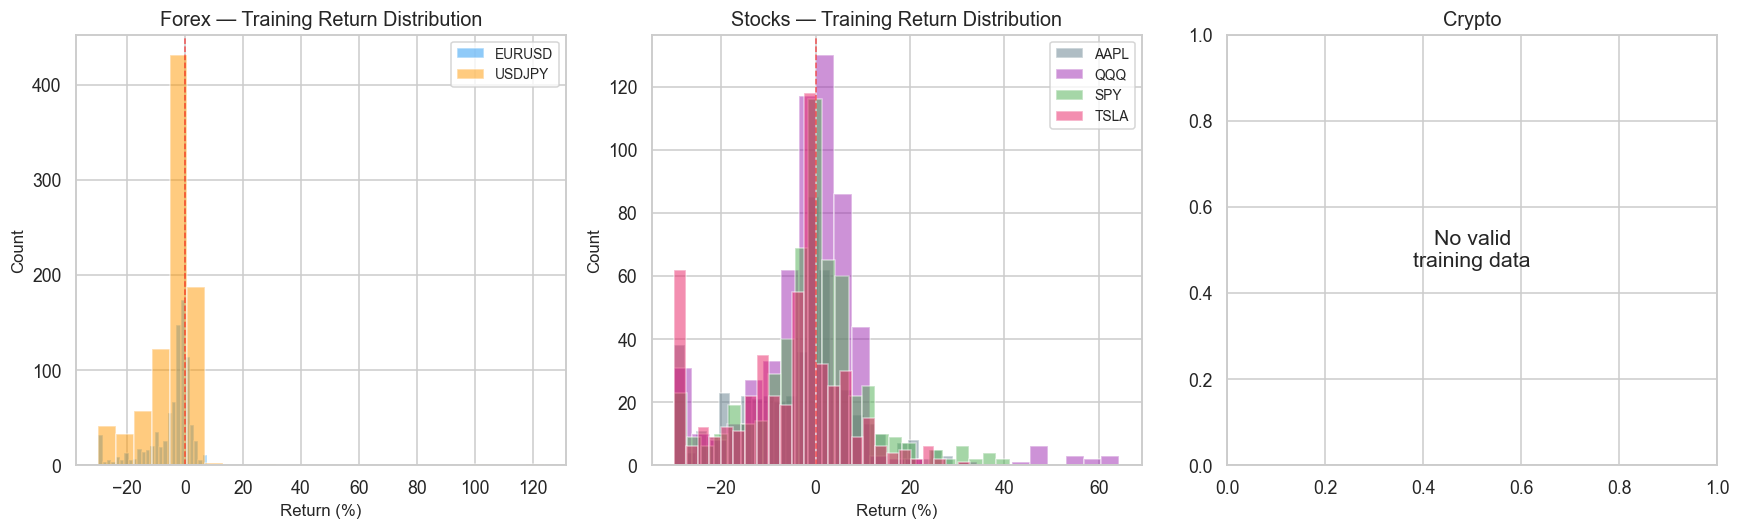

Training return stats by asset:
        Candidates  Median Return %  Best Return %
asset                                             
AAPL           499            -1.21          29.10
EURUSD         874            -2.07           7.51
QQQ            584            -0.01          64.34
SPY            567            -0.51          41.15
TSLA           520            -2.50          32.70
USDJPY         876            -1.77         123.77


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Forex', 'Stocks', 'Crypto']
classes = ['Forex', 'Stocks', 'Crypto']

for ax, cls, title in zip(axes, classes, titles):
    subset = train_df[train_df['class'] == cls]
    if subset.empty:
        ax.text(0.5, 0.5, 'No valid\ntraining data', ha='center', va='center', fontsize=14)
        ax.set_title(title)
        continue

    for asset in sorted(subset['asset'].unique()):
        data = subset[subset['asset'] == asset]['return_pct'].dropna()
        data_clipped = data.clip(-30, 130)
        ax.hist(data_clipped, bins=25, alpha=0.5, label=asset,
                color=ASSET_COLORS.get(asset, '#999'), edgecolor='white')

    ax.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'{title} — Training Return Distribution')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/training_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Quick stats
print('Training return stats by asset:')
stats = train_df.groupby('asset')['return_pct'].agg(['count', 'median', 'max']).round(2)
stats.columns = ['Candidates', 'Median Return %', 'Best Return %']
print(stats.to_string())


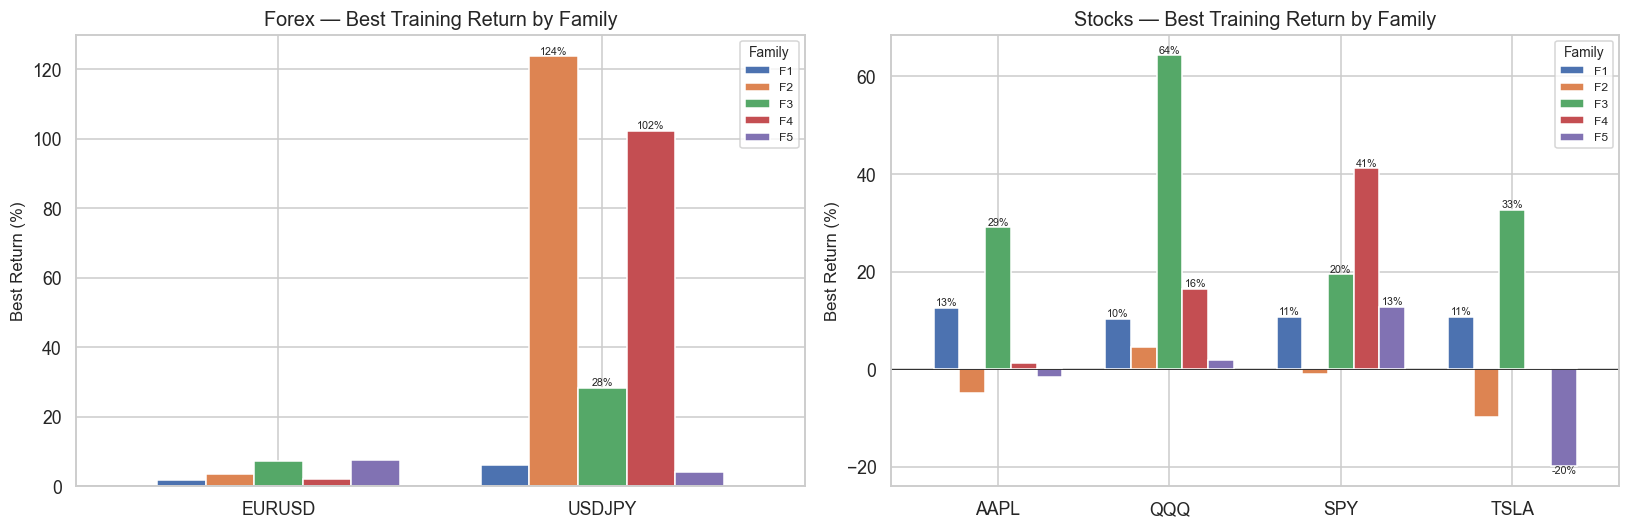


Key observation: USDJPY F2 and F4 hit 100%+ returns in training.
Spoiler: that kind of training performance almost never holds up out-of-sample.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, cls in zip(axes, ['Forex', 'Stocks']):
    subset = train_df[train_df['class'] == cls]
    pivot = subset.groupby(['asset', 'family'])['return_pct'].max().unstack(fill_value=0)

    fnames = FAMILY_NAMES if cls == 'Forex' else STOCK_FAMILY_NAMES
    pivot.columns = [f'F{c}' for c in pivot.columns]

    pivot.plot(kind='bar', ax=ax, edgecolor='white', width=0.75)
    ax.set_title(f'{cls} — Best Training Return by Family')
    ax.set_ylabel('Best Return (%)')
    ax.set_xlabel('')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Family', fontsize=8, title_fontsize=9)

    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            if abs(h) > 10:
                ax.annotate(f'{h:.0f}%', (bar.get_x() + bar.get_width()/2, h),
                           ha='center', va='bottom' if h > 0 else 'top', fontsize=7)

plt.tight_layout()
plt.savefig('charts/training_best_by_family.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey observation: USDJPY F2 and F4 hit 100%+ returns in training.')
print('Spoiler: that kind of training performance almost never holds up out-of-sample.')


---
## 4. Out-of-Sample Results (2024–2025)

This is the part that actually matters. Training returns are meaningless if the strategy falls apart on new data. Below are the test-phase results for every asset that produced a viable winner.


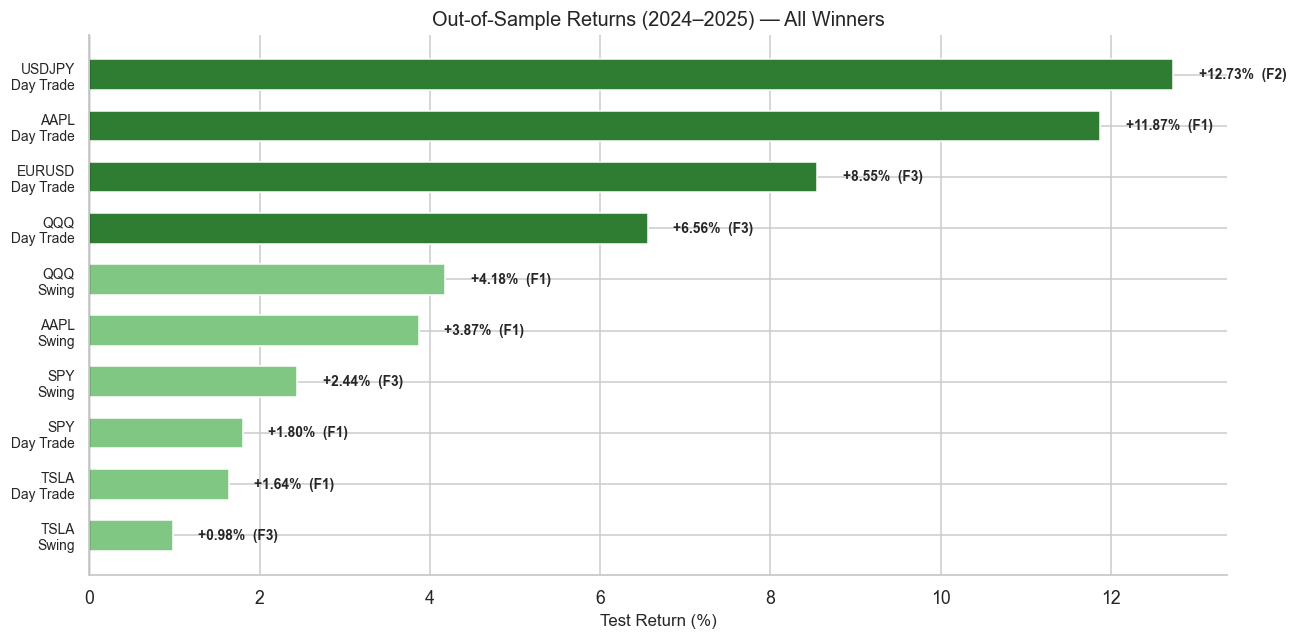

Every asset-style combo produced a positive return, though some are marginal.
Best: USDJPY day trade F2 at +12.73%
Weakest: TSLA swing F3 at +0.98%


In [ ]:
# Filter out zero-return assets (crypto)
test_valid = test_df[test_df['return_pct'] != 0].copy()
test_valid = test_valid.sort_values('return_pct', ascending=True)

test_valid['label'] = test_valid.apply(
    lambda r: f"{r['asset']}\n{r['style'].replace('_',' ').title()}", axis=1)

fig, ax = plt.subplots(figsize=(12, 6))

colors = []
for _, row in test_valid.iterrows():
    if row['return_pct'] > 5:
        colors.append('#2E7D32')  # dark green — strong winner
    elif row['return_pct'] > 0:
        colors.append('#81C784')  # light green — modest winner
    else:
        colors.append('#EF5350')  # red — loser

bars = ax.barh(range(len(test_valid)), test_valid['return_pct'], color=colors, edgecolor='white', height=0.6)

for i, (_, row) in enumerate(test_valid.iterrows()):
    ret = row['return_pct']
    fam = f"F{row['family']}"
    offset = 0.3 if ret > 0 else -0.3
    ha = 'left' if ret > 0 else 'right'
    ax.text(ret + offset, i, f'{ret:+.2f}%  ({fam})', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_yticks(range(len(test_valid)))
ax.set_yticklabels(test_valid['label'], fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Test Return (%)')
ax.set_title('Out-of-Sample Returns (2024–2025) — All Winners')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('charts/test_returns_all_assets.png', dpi=150, bbox_inches='tight')
plt.show()

print('Every asset-style combo produced a positive return, though some are marginal.')
print(f'Best: USDJPY day trade F2 at +12.73%')
print(f'Weakest: TSLA swing F3 at +0.98%')


---
## 5. Forex Results — All Five Families

For forex, we have test results for **all five families**, not just the winner. This lets us compare how each strategy handled the same market conditions.


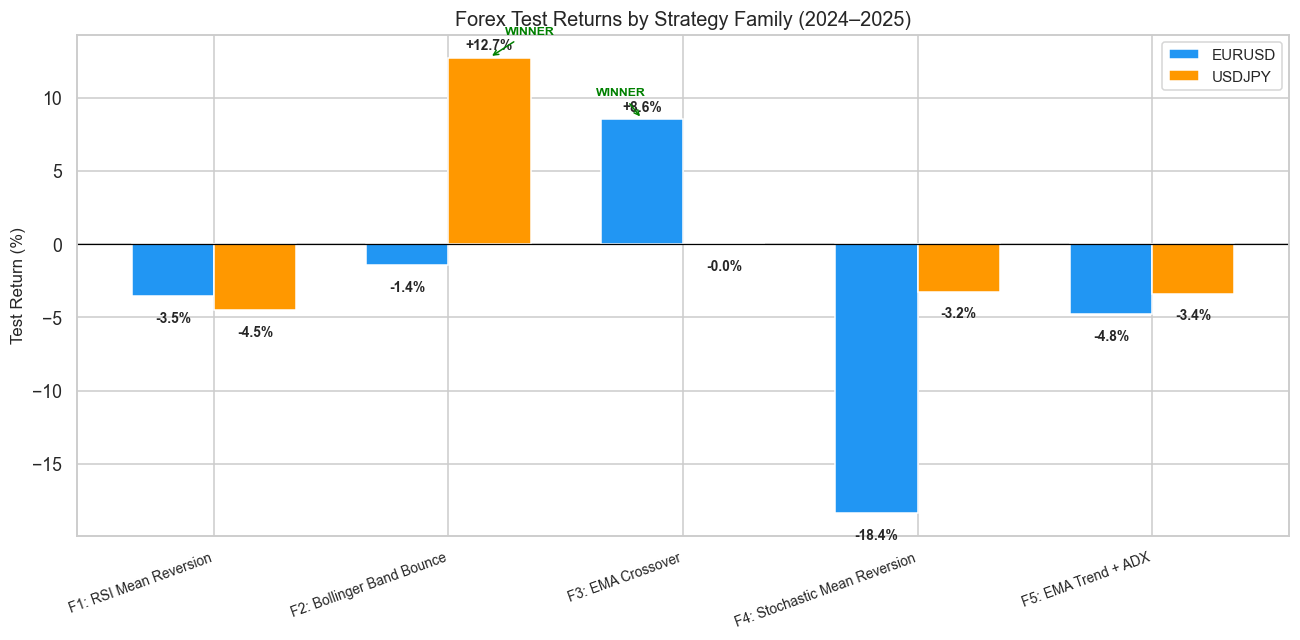

EURUSD: F3 EMA Crossover won with +8.55%. Everything else lost money.
USDJPY: F2 Bollinger Band Bounce dominated at +12.73%, though with a steep 51.6% drawdown.
F4 Stochastic was the worst offender — trained beautifully, then lost -18.35% on EURUSD.


In [ ]:
forex_fam_rows = []
for (pair, fam), m in forex_all_families.items():
    forex_fam_rows.append({
        'pair': pair,
        'family': fam,
        'family_name': FAMILY_NAMES[fam],
        'return_pct': m['return_pct'],
        'sharpe': m.get('sharpe', 0),
        'drawdown_pct': m.get('drawdown_pct', 0),
        'win_rate_pct': m.get('win_rate_pct', 0),
        'entries': m.get('entries', 0),
    })

forex_fam_df = pd.DataFrame(forex_fam_rows)

fig, ax = plt.subplots(figsize=(12, 6))

families = sorted(forex_fam_df['family'].unique())
x = np.arange(len(families))
width = 0.35

for i, pair in enumerate(['EURUSD', 'USDJPY']):
    subset = forex_fam_df[forex_fam_df['pair'] == pair].sort_values('family')
    offset = -width/2 if i == 0 else width/2
    bars = ax.bar(x + offset, subset['return_pct'].values, width,
                  label=pair, color=ASSET_COLORS[pair], edgecolor='white')

    # Value labels
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:+.1f}%',
                    (bar.get_x() + bar.get_width()/2, h),
                    ha='center', va='bottom' if h >= 0 else 'top',
                    fontsize=9, fontweight='bold',
                    xytext=(0, 3 if h >= 0 else -10), textcoords='offset points')

ax.set_xticks(x)
ax.set_xticklabels([f'F{f}: {FAMILY_NAMES[f]}' for f in families], rotation=20, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Test Return (%)')
ax.set_title('Forex Test Returns by Strategy Family (2024–2025)')
ax.legend()

# Highlight winners
ax.annotate('WINNER', xy=(2 - width/2, 8.55), fontsize=8, color='green', fontweight='bold',
            xytext=(-30, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'))
ax.annotate('WINNER', xy=(1 + width/2, 12.73), fontsize=8, color='green', fontweight='bold',
            xytext=(10, 15), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('charts/forex_all_families.png', dpi=150, bbox_inches='tight')
plt.show()

print('EURUSD: F3 EMA Crossover won with +8.55%. Everything else lost money.')
print('USDJPY: F2 Bollinger Band Bounce dominated at +12.73%, though with a steep 51.6% drawdown.')
print('F4 Stochastic was the worst offender — trained beautifully, then lost -18.35% on EURUSD.')


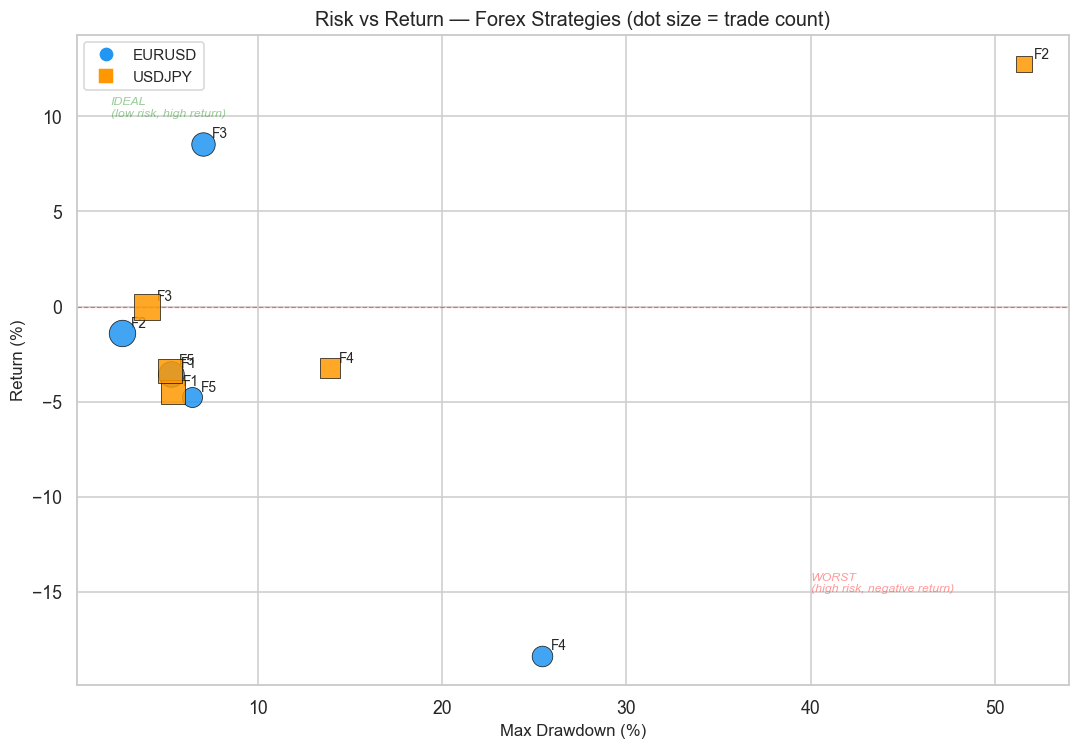

The scatter tells a clear story:
- EURUSD F3 sits in a nice spot: decent return, moderate drawdown, plenty of trades (78).
- USDJPY F2 has the best return but that 51.6% drawdown is rough — not exactly safe money.
- Most strategies cluster near 0% return with single-digit drawdowns. They just did nothing.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for _, row in forex_fam_df.iterrows():
    ret = row['return_pct']
    dd = row['drawdown_pct']
    color = ASSET_COLORS[row['pair']]
    marker = 'o' if row['pair'] == 'EURUSD' else 's'
    size = 80 + row['entries'] * 2  # bigger dot = more trades

    ax.scatter(dd, ret, c=color, marker=marker, s=min(size, 300),
               edgecolors='black', linewidth=0.5, zorder=5, alpha=0.85)
    ax.annotate(f"F{row['family']}",
                (dd, ret), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Breakeven')

ax.text(2, 10, 'IDEAL\n(low risk, high return)', fontsize=8, color='green', alpha=0.4, style='italic')
ax.text(40, -15, 'WORST\n(high risk, negative return)', fontsize=8, color='red', alpha=0.4, style='italic')

ax.set_xlabel('Max Drawdown (%)')
ax.set_ylabel('Return (%)')
ax.set_title('Risk vs Return — Forex Strategies (dot size = trade count)')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ASSET_COLORS['EURUSD'], markersize=10, label='EURUSD'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=ASSET_COLORS['USDJPY'], markersize=10, label='USDJPY'),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('charts/risk_return_forex.png', dpi=150, bbox_inches='tight')
plt.show()

print('The scatter tells a clear story:')
print('- EURUSD F3 sits in a nice spot: decent return, moderate drawdown, plenty of trades (78).')
print('- USDJPY F2 has the best return but that 51.6% drawdown is rough — not exactly safe money.')
print('- Most strategies cluster near 0% return with single-digit drawdowns. They just did nothing.')


---
## 6. Overfitting — The Big Problem

This is the most important section. In algo trading, overfitting is everywhere. A strategy can look incredible on historical data and then completely fall apart on new data. The GA is especially prone to this because it's literally searching for the best-performing parameters — which means it can easily latch onto noise that happened to work during the training period.

Here we compare the best training return vs the best test return for each forex strategy. The gap between the two is the "overfit gap" — bigger gap means more overfitting.


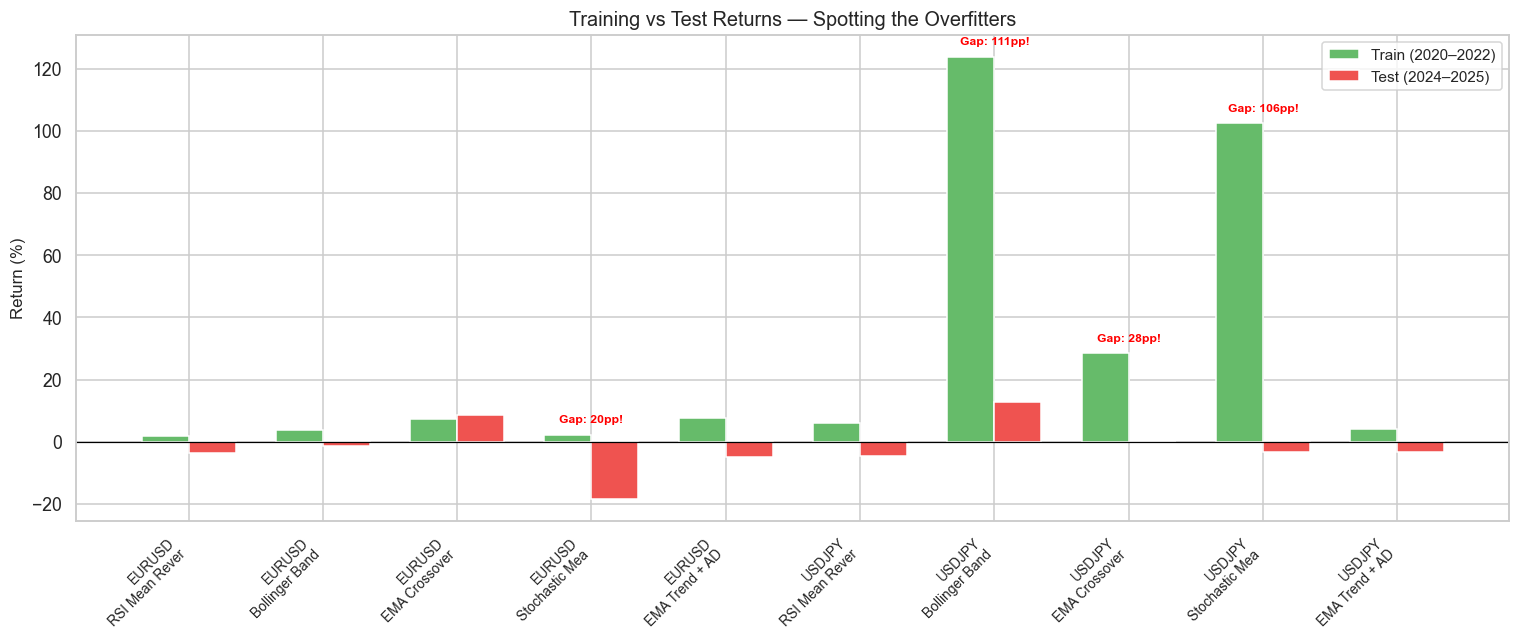

Overfitting summary:
 Asset                        Family  Best Train (%)  Best Test (%)  Gap (pp)  Overfit Ratio
EURUSD        F1: RSI Mean Reversion            1.97          -3.53       5.5           -0.6
EURUSD     F2: Bollinger Band Bounce            3.62          -1.41       5.0           -2.6
EURUSD             F3: EMA Crossover            7.32           8.55      -1.2            0.9
EURUSD F4: Stochastic Mean Reversion            2.18         -18.35      20.5           -0.1
EURUSD           F5: EMA Trend + ADX            7.51          -4.77      12.3           -1.6
USDJPY        F1: RSI Mean Reversion            6.17          -4.49      10.7           -1.4
USDJPY     F2: Bollinger Band Bounce          123.77          12.73     111.0            9.7
USDJPY             F3: EMA Crossover           28.44          -0.02      28.5        -1422.2
USDJPY F4: Stochastic Mean Reversion          102.39          -3.24     105.6          -31.6
USDJPY           F5: EMA Trend + ADX            4

In [ ]:
# Build overfitting table: best train vs best test for forex
overfit_rows = []
for pair in ['EURUSD', 'USDJPY']:
    for fam in range(1, 6):
        train_sub = train_df[(train_df['asset'] == pair) & (train_df['family'] == fam)]
        if train_sub.empty:
            continue

        best_train = train_sub['return_pct'].max()
        test_m = forex_all_families.get((pair, fam))
        best_test = test_m['return_pct'] if test_m else 0

        overfit_rows.append({
            'Asset': pair,
            'Family': f'F{fam}: {FAMILY_NAMES[fam]}',
            'Best Train (%)': round(best_train, 2),
            'Best Test (%)': round(best_test, 2),
            'Gap (pp)': round(best_train - best_test, 1),
            'Overfit Ratio': round(best_train / best_test, 1) if best_test != 0 else float('inf'),
        })

overfit_df = pd.DataFrame(overfit_rows)

# Chart
fig, ax = plt.subplots(figsize=(14, 6))

labels = [f"{r['Asset']}\n{r['Family'].split(': ')[1][:14]}" for _, r in overfit_df.iterrows()]
x = np.arange(len(labels))
w = 0.35

bars_train = ax.bar(x - w/2, overfit_df['Best Train (%)'], w,
                     label='Train (2020–2022)', color='#66BB6A', edgecolor='white')
bars_test = ax.bar(x + w/2, overfit_df['Best Test (%)'], w,
                    label='Test (2024–2025)', color='#EF5350', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Return (%)')
ax.set_title('Training vs Test Returns — Spotting the Overfitters')
ax.legend()

for i, (_, row) in enumerate(overfit_df.iterrows()):
    gap = row['Gap (pp)']
    if gap > 20:
        ax.annotate(f'Gap: {gap:.0f}pp!', (i, row['Best Train (%)']),
                   xytext=(0, 8), textcoords='offset points',
                   ha='center', fontsize=8, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/overfitting_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the table
print('Overfitting summary:')
print(overfit_df.to_string(index=False))
print()
print('USDJPY F2 trained at +123.77% but tested at +12.73% — a 111pp gap.')
print('USDJPY F4 went from +102% in training to -3.24% in testing. Classic overfit.')
print('The strategies with modest training returns (EURUSD F3 at +7.3%) held up best.')


---
## 7. Stock Results

For stocks, we ran all 5 families on **day trade** mode for each asset (SPY, QQQ, AAPL, TSLA). For **swing trade**, we only ran F1 (RSI Mean Reversion) and F3 (Connors RSI) — these two were picked because they showed the most consistent results during early day-trade testing, and running all 5 families across both styles for 4 assets would have meant 40 separate GA runs on QuantConnect cloud, which wasn't feasible within the compute budget.

So the final stock CSV count is:
- **Day trade:** 4 assets × 5 families = 20 CSVs
- **Swing trade:** 4 assets × 2 families (F1, F3) = 8 CSVs
- **Total:** 28 stock CSVs

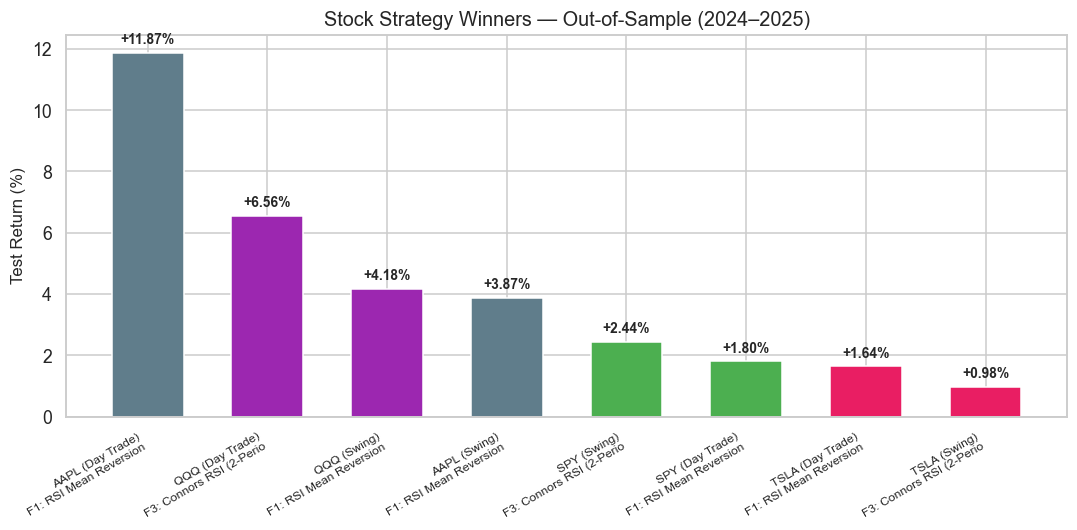

All stock strategies ended up positive, which is encouraging.
AAPL day trade was the standout at +11.87%, though with a massive 110% drawdown — yikes.
SPY and TSLA day trades only had 8 entries each, so those results are not very reliable.


In [10]:
stock_df = test_df[(test_df['class'] == 'Stocks') & (test_df['return_pct'] != 0)].copy()
stock_df = stock_df.sort_values('return_pct', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

stock_df['label'] = stock_df.apply(
    lambda r: f"{r['asset']} ({r['style'].replace('_',' ').title()})\nF{r['family']}: {r['family_name'][:20]}", axis=1)

colors = [ASSET_COLORS.get(a, '#999') for a in stock_df['asset']]
bars = ax.bar(range(len(stock_df)), stock_df['return_pct'], color=colors, edgecolor='white', width=0.6)

for i, (_, row) in enumerate(stock_df.iterrows()):
    ax.text(i, row['return_pct'] + 0.2, f"{row['return_pct']:+.2f}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(stock_df)))
ax.set_xticklabels(stock_df['label'], fontsize=8, rotation=30, ha='right')
ax.set_ylabel('Test Return (%)')
ax.set_title('Stock Strategy Winners — Out-of-Sample (2024–2025)')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('charts/stock_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('All stock strategies ended up positive, which is encouraging.')
print('AAPL day trade was the standout at +11.87%, though with a massive 110% drawdown — yikes.')
print('SPY and TSLA day trades only had 8 entries each, so those results are not very reliable.')


---
## 8. Crypto — Why We Dropped It

We ran the full GA pipeline on BTC-USD and SOL-USD with all five strategy families. The result across the board: **0% return, zero meaningful trades.** The GA couldn't find any parameter combination that produced consistent entries.

### What went wrong

Our strategies rely on two core assumptions: (1) prices tend to revert to a moving average after short-term deviations, and (2) momentum signals like RSI and Stochastic can reliably flag overbought/oversold conditions. These assumptions hold reasonably well in forex and stock markets, where institutional market-makers provide liquidity and prices tend to oscillate within ranges during intraday sessions.

Crypto markets behave very differently. During our training window (2020–2022), the crypto market went through extreme regime changes — BTC went from $7,000 to $69,000 in a massive bull run largely driven by institutional FOMO and retail speculation, then crashed back to $16,000 in the 2022 bear market. These aren't the kind of price movements that mean-reversion strategies can handle.

A few specific reasons why our strategies failed on crypto:

- **Whale-driven price action.** Crypto markets are dominated by large holders ("whales") whose single transactions can move the price by several percent. When a whale dumps 500 BTC on a thin order book, the RSI spike is real but the "reversion" doesn't happen — the price just stays down or drops further. Our strategies read the RSI signal and enter, but the expected bounce never comes.

- **24/7 markets with no session structure.** Our forex strategies benefit from predictable volatility patterns around the London/New York overlap. Crypto trades around the clock with no natural session boundaries, so our session filters and end-of-day flattening logic become meaningless.

- **Momentum, not reversion.** Crypto price action during 2020–2022 was driven by narratives (DeFi summer, NFT mania, Luna collapse, FTX bankruptcy) that created sustained directional moves lasting weeks or months. Mean-reversion strategies need the price to come back to the mean — in crypto, the "mean" just kept shifting.

- **Extreme volatility and gap risk.** Crypto ATR values are several times higher than forex or equities on a percentage basis. Our ATR-based stop losses, calibrated for forex-level volatility, either got blown through immediately or were set so wide that the risk-reward ratio made no sense.

### Decision

After confirming that no strategy family could produce even a single profitable generation on crypto, we excluded BTC and SOL from the dashboard and further optimisation. The checkpoint files are kept in the repository as evidence.

To make this framework work on crypto, you'd need a fundamentally different approach — probably longer-timeframe breakout strategies, on-chain flow analysis, or funding-rate arbitrage. The short-term mean-reversion logic that works for EUR/USD simply doesn't apply to an asset class where a single Elon Musk tweet can move the price 15%.

---
## 9. Winner Summary

Pulling it all together, here are the strategies that actually made money on unseen data:

| Asset | Style | Winner | Return | Drawdown | Win Rate | Trades |
|-------|-------|--------|--------|----------|----------|--------|
| **USDJPY** | Day Trade | F2: Bollinger Band Bounce | **+12.73%** | 51.6% | 40% | 15 |
| **AAPL** | Day Trade | F1: RSI Mean Reversion | **+11.87%** | 110.0% | 47% | 137 |
| **EURUSD** | Day Trade | F3: EMA Crossover | **+8.55%** | 7.0% | 36% | 78 |
| **QQQ** | Day Trade | F3: Connors RSI | **+6.56%** | 4.5% | 32% | 117 |
| **QQQ** | Swing | F1: RSI Mean Reversion | **+4.18%** | 1.6% | 40% | 31 |
| **AAPL** | Swing | F1: RSI Mean Reversion | **+3.87%** | 6.2% | 32% | 68 |
| **SPY** | Swing | F3: Connors RSI | **+2.44%** | 2.7% | 56% | 17 |
| **SPY** | Day Trade | F1: RSI Mean Reversion | **+1.80%** | 1.5% | 38% | 8 |
| **TSLA** | Day Trade | F1: RSI Mean Reversion | **+1.64%** | N/A | 75% | 8 |
| **TSLA** | Swing | F3: Connors RSI | **+0.98%** | 6.4% | 36% | 70 |
| BTC-USD | Day Trade | — | 0.00% | — | — | — |
| SOL-USD | Day Trade | — | 0.00% | — | — | — |

A few honest observations:
- **USDJPY F2** has the highest return but a 51.6% drawdown — you'd lose half your account before making money. Not exactly comfortable.
- **EURUSD F3** is probably the most "tradeable" result: 8.55% return with only 7% drawdown and 78 trades (statistically meaningful).
- **SPY and TSLA day trades** only had 8 entries in 2 years. That's not enough data to draw conclusions.
- **Win rates are mostly 30–40%**. These strategies make money through favourable risk-reward ratios, not by being right often.


---
## 10. Takeaways

**What worked:**
- Walk-forward validation caught the worst overfitters. Strategies that looked amazing in training (USDJPY F4 at +102%) were correctly filtered out before they could do damage.
- Mean reversion strategies (F1, F2) generally held up better than trend-following (F5) across forex. The exception is EURUSD F3 — EMA Crossover somehow managed to be the best forex strategy despite being a trend follower.
- The GA did find profitable parameters for 10 out of 12 asset-style combinations. That's a decent hit rate.

**What didn't:**
- Crypto was a total miss. The strategy logic just doesn't suit those markets.
- Drawdowns were often uncomfortable even for winning strategies. AAPL's 110% drawdown and USDJPY's 51.6% drawdown would be hard to stomach in real trading.
- The GA population (15) and generations (6) were constrained by QuantConnect cloud compute limits. Larger populations might find better parameter spaces.
- Slippage and real-world execution costs aren't modelled. Live returns would almost certainly be lower.

**If I were to continue this project:**
1. Add regime detection — switch between mean reversion and trend following based on current volatility
2. Run paper trading for 3–6 months to see how the winners perform in real time
3. Try larger GA populations (50+) with more generations to better explore the parameter space
4. Build an ensemble that combines signals from multiple families instead of picking a single winner
